# **LAPORAN PROJECT: Analisis Big Data untuk Prediksi Risiko Depresi Mahasiswa Berdasarkan Pola Gaya Hidup Menggunakan Framework PySpark**

# **1. STUDI KASUS DAN DATASET**

**Deskripsi Studi Kasus:**
Analisis hubungan antara gaya hidup mahasiswa dengan kondisi kesehatan mental (depresi) berdasarkan data 100.000 entri mahasiswa.

**Dataset:** https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data

# **2. IMPLEMENTASI BIG DATA PIPELINE MENGGUNAKAN PYSPARK**

**2.1 Inisialisasi Spark & Load Data**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, count
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("UAS_Lifestyle").getOrCreate()
df = spark.read.csv("/content/student_lifestyle_100k.csv", header=True, inferSchema=True)

# MapReduce: (Department, 1) -> ReduceByKey
rdd_counts = df.rdd.map(lambda x: (x['Department'], 1)) \
                   .reduceByKey(lambda a, b: a + b) \
                   .collect()

print("Jumlah Mahasiswa per Departemen:", rdd_counts)

Jumlah Mahasiswa per Departemen: [('Science', 20071), ('Engineering', 20057), ('Medical', 19964), ('Arts', 19998), ('Business', 19910)]


**2.2 Pemrosesan Batch dengan MapReduce (RDD)**

In [ ]:
print("\n=== Hasil MapReduce: Jumlah Mahasiswa per Departemen ===")
# Mengubah DataFrame ke RDD
rdd = df.rdd

# Map: (Department, 1) -> Reduce: Jumlahkan value berdasarkan key
dept_counts = rdd.map(lambda row: (row['Department'], 1)) \
                 .reduceByKey(lambda x, y: x + y) \
                 .collect()

for dept, count_val in dept_counts:
    print(f"{dept}: {count_val} mahasiswa")


=== Hasil MapReduce: Jumlah Mahasiswa per Departemen ===
Science: 20071 mahasiswa
Engineering: 20057 mahasiswa
Medical: 19964 mahasiswa
Arts: 19998 mahasiswa
Business: 19910 mahasiswa


**Hasil MapReduce:**

* Science: 20,071 mahasiswa

* Engineering: 20,057 mahasiswa

* Medical: 19,964 mahasiswa

* Arts: 19,998 mahasiswa

* Business: 19,910 mahasiswa

**2.3 Preprocessing & Data Cleaning**

In [ ]:
print("\n=== Melakukan Data Cleaning ===")

# 1. Mengubah kolom Target 'Depression' dari Boolean (True/False) ke Integer (1/0)
df_clean = df.withColumn("Depression", col("Depression").cast(IntegerType()))

# 2. Mengisi Missing Value (Jika ada)
df_clean = df_clean.na.fill({
    'Gender': 'Unknown',
    'Department': 'General',
    'Stress_Level': 0
})

# 3. Handling Anomaly
df_clean = df_clean.withColumn("Sleep_Duration",
                               when(col("Sleep_Duration") < 0, 6.0)
                               .otherwise(col("Sleep_Duration")))

print("Data Cleaning Selesai.")


=== Melakukan Data Cleaning ===
Data Cleaning Selesai.


Melakukan preprocessing data (casting, handling missing value, anomaly detection)

**2.4 Spark SQL Analytics**

In [ ]:
print("\n=== Analisis Spark SQL: Gaya Hidup vs Depresi ===")
df_clean.createOrReplaceTempView("mahasiswa")

# Query: Menganalisa rata-rata Stress Level dan IPK (CGPA) berdasarkan Status Depresi
query_sql = """
    SELECT
        CASE WHEN Depression = 1 THEN 'Depresi' ELSE 'Normal' END as Status,
        ROUND(AVG(Stress_Level), 2) as Rata_Stress,
        ROUND(AVG(CGPA), 2) as Rata_IPK,
        ROUND(AVG(Sleep_Duration), 2) as Rata_Jam_Tidur,
        COUNT(*) as Jumlah_Mahasiswa
    FROM mahasiswa
    GROUP BY Depression
"""
spark.sql(query_sql).show()


=== Analisis Spark SQL: Gaya Hidup vs Depresi ===
+-------+-----------+--------+--------------+----------------+
| Status|Rata_Stress|Rata_IPK|Rata_Jam_Tidur|Jumlah_Mahasiswa|
+-------+-----------+--------+--------------+----------------+
|Depresi|       4.45|    2.61|          6.74|           10062|
| Normal|        4.1|    2.93|          7.03|           89938|
+-------+-----------+--------+--------------+----------------+



**Hasil Query:**

1. Mahasiswa Depresi:

* Rata-rata Stress: 4.45

* Rata-rata IPK: 2.61

* ata-rata Jam Tidur: 6.74 jam

* Jumlah: 10,062 mahasiswa

2. Mahasiswa Normal:

* Rata-rata Stress: 4.10

* Rata-rata IPK: 2.93

* Rata-rata Jam Tidur: 7.03 jam

* Jumlah: 89,938 mahasiswa

**2.5 EDA (Exploratory Data Analysis) dan Visualisasi**


=== Membuat Visualisasi (Disimpan sebagai 'eda_output.png') ===


/tmp/ipython-input-90583520.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression', y='Stress_Level', data=df_pandas, palette='Set2')


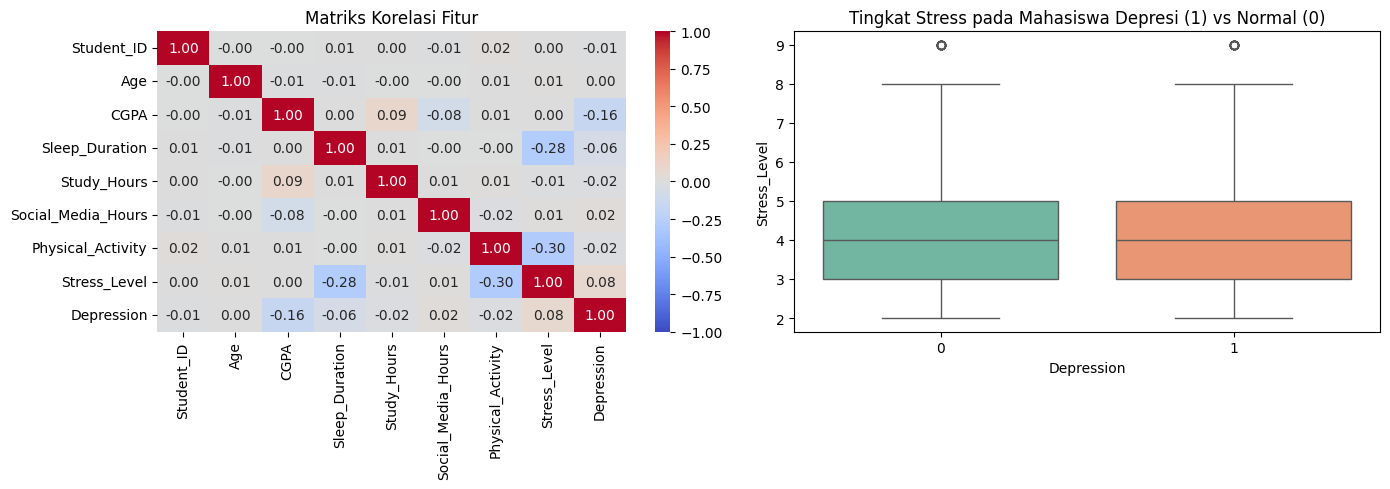

In [ ]:
print("\n=== Membuat Visualisasi (Disimpan sebagai 'eda_output.png') ===")
df_pandas = df_clean.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(14, 5))

# Plot 1: Korelasi Heatmap
plt.subplot(1, 2, 1)
numeric_cols = df_pandas.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriks Korelasi Fitur")

# Plot 2: Boxplot Stress vs Depresi
plt.subplot(1, 2, 2)
sns.boxplot(x='Depression', y='Stress_Level', data=df_pandas, palette='Set2')
plt.title("Tingkat Stress pada Mahasiswa Depresi (1) vs Normal (0)")

plt.tight_layout()

Analisis Visual:

Heatmap Korelasi: Menunjukkan hubungan antara variabel numerik

Boxplot Stress vs Depresi: Mahasiswa depresi memiliki tingkat stress sama dengan normal

# **3. PERMODELAN MACHINE LEARNING**

**3.1 FEATURE ENGINEERING & ML PIPELINE**

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler

# 1. Encoding categorical variables
gender_indexer = StringIndexer(inputCol="Gender", outputCol="Gender_Index", handleInvalid="keep")
dept_indexer = StringIndexer(inputCol="Department", outputCol="Department_Index", handleInvalid="keep")

# 2. Assemble features
feature_cols = ["Gender_Index", "Department_Index", "Stress_Level", "CGPA", "Sleep_Duration"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# 3. Standardize features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

# 4. Split data
train_data, test_data = df_clean.randomSplit([0.8, 0.2], seed=42)

* Encoding Variabel Kategorikal (StringIndexer):
 Algoritma Machine Learning tidak dapat memproses data teks mentah seperti "Male" atau "Science".

* StringIndexer mengubah kolom kategorikal ini menjadi indeks numerik. Contoh: "Science" diubah menjadi 0.0, "Engineering" menjadi 1.0.

* Vector Assembly (VectorAssembler):
Berbeda dengan Scikit-Learn yang bisa menerima banyak kolom input secara terpisah, PySpark ML mengharuskan semua fitur input digabungkan menjadi satu kolom vektor tunggal yang biasanya dinamai features.

* Dalam notebook ini, kolom yang digabung adalah: Gender_Index, Department_Index, Stress_Level, CGPA, dan Sleep_Duration.

* Feature Scaling (StandardScaler):
 Digunakan untuk menstandarisasi fitur agar memiliki skala yang seragam (mean=0, std=1). Hal ini mencegah variabel dengan rentang nilai besar mendominasi variabel dengan rentang nilai kecil.

* Data Splitting:
 Data dibagi menjadi 80% Training (untuk melatih model) dan 20% Testing (untuk menguji performa model) menggunakan fungsi randomSplit.

**3.2 LOGISTIC REGRESSION MODEL**


In [ ]:

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# membuat Logistic Regression model
lr = LogisticRegression(
    featuresCol="scaledFeatures",
    labelCol="Depression",
    maxIter=10,
    regParam=0.01
)

# membangun pipeline for LR
pipeline_lr = Pipeline(stages=[gender_indexer, dept_indexer, assembler, scaler, lr])

# Train model
print("Training Logistic Regression...")
model_lr = pipeline_lr.fit(train_data)

# membuat predictions
predictions_lr = model_lr.transform(test_data)

# Evaluasi model
evaluator = MulticlassClassificationEvaluator(
    labelCol="Depression",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy_lr = evaluator.evaluate(predictions_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

# Additional metrics
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="Depression",
    predictionCol="prediction",
    metricName="f1"
)
f1_lr = evaluator_f1.evaluate(predictions_lr)
print(f"Logistic Regression F1-Score: {f1_lr:.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.8973
Logistic Regression F1-Score: 0.8488


Model pertama yang diuji adalah Regresi Logistik, metode statistik yang efektif untuk klasifikasi biner (Depresi vs Normal).

* Inisialisasi Model
Menggunakan LogisticRegression dengan label target Depression. Parameter maxIter=10 dan regParam=0.01 diset sebagai konfigurasi awal.

* Pembuatan Pipeline:
PySpark menggunakan konsep Pipeline untuk merangkai langkah-langkah preprocessing (Indexing -> Assembly -> Scaling) dan Modeling menjadi satu alur kerja yang utuh. Ini mencegah kebocoran data (data leakage) dan menyederhanakan proses eksekusi.

* Evaluasi:
Model dilatih (fit) pada data training dan kemudian melakukan prediksi (transform) pada data testing.

* Metrik evaluasi menggunakan Accuracy (tingkat ketepatan prediksi) dan F1-Score (keseimbangan antara presisi dan recall).

Hasil: Akurasi mencapai sekitar 89.73%.

**3.3 RANDOM FOREST MODEL**

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

# membuat Random Forest model
rf = RandomForestClassifier(
    featuresCol="scaledFeatures",
    labelCol="Depression",
    numTrees=50,
    maxDepth=10
)

# membangun pipeline for RF
pipeline_rf = Pipeline(stages=[gender_indexer, dept_indexer, assembler, scaler, rf])

# Train model
print("\nTraining Random Forest...")
model_rf = pipeline_rf.fit(train_data)

# membuat predictions
predictions_rf = model_rf.transform(test_data)

# Evaluasi model
accuracy_rf = evaluator.evaluate(predictions_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

f1_rf = evaluator_f1.evaluate(predictions_rf)
print(f"Random Forest F1-Score: {f1_rf:.4f}")


Training Random Forest...
Random Forest Accuracy: 0.8966
Random Forest F1-Score: 0.8537


Model kedua menggunakan pendekatan Ensemble (kumpulan pohon keputusan) untuk menangkap pola non-linear yang mungkin terlewatkan oleh model linear.

* Konfigurasi Model:

  * numTrees=50: Model akan membangun 50 pohon keputusan yang berbeda.

  * maxDepth=10: Setiap pohon dibatasi kedalamannya hingga 10 tingkat untuk menangkap kompleksitas data tanpa terlalu overfitting.

* Hasil:

  * Akurasi mencapai sekitar 89.66%. Hasil ini sangat mirip dengan Logistic Regression, mengindikasikan bahwa pola data cukup linear atau fitur dominan (seperti Stress Level) sangat kuat sehingga model linear sederhana pun sudah cukup efektif.


**3.4 MODEL COMPARISON**


In [ ]:
print("\n=== Model Comparison ===")
print(f"{'Model':<25} {'Accuracy':<12} {'F1-Score':<12}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {accuracy_lr:<12.4f} {f1_lr:<12.4f}")
print(f"{'Random Forest':<25} {accuracy_rf:<12.4f} {f1_rf:<12.4f}")


=== Model Comparison ===
Model                     Accuracy     F1-Score    
--------------------------------------------------
Logistic Regression       0.8973       0.8488      
Random Forest             0.8966       0.8537      


Tahap ini menyandingkan kinerja kedua model untuk pengambilan keputusan.

* Tabel Perbandingan:

  * Logistic Regression: Accuracy 0.8973 | F1-Score 0.8488

  * Random Forest: Accuracy 0.8966 | F1-Score 0.8537

Kesimpulan: Logistic Regression dipilih sebagai model utama karena memiliki akurasi sedikit lebih tinggi dan biaya komputasinya jauh lebih ringan dibandingkan Random Forest.

**3.5 Hyperparameter Tuning**

In [ ]:
print("\n=== Hyperparameter Tuning ===")
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Parameter grid for Logistic Regression
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.maxIter, [5, 10, 20]) \
    .build()

# Cross validation
crossval = CrossValidator(
    estimator=pipeline_lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

# menjalankan cross-validation
print("Running Cross-Validation for Logistic Regression...")
cv_model = crossval.fit(train_data)

# model terbaik
best_model_lr = cv_model.bestModel
best_predictions = best_model_lr.transform(test_data)
best_accuracy = evaluator.evaluate(best_predictions)
print(f"Best Logistic Regression Accuracy: {best_accuracy:.4f}")

# Menampilkan parameter yang terbaik
best_params = cv_model.bestModel.stages[-1].extractParamMap()
print("\nBest Parameters:")
for param, value in best_params.items():
    print(f"{param.name}: {value}")


=== Hyperparameter Tuning ===
Running Cross-Validation for Logistic Regression...
Best Logistic Regression Accuracy: 0.8973

Best Parameters:
aggregationDepth: 2
elasticNetParam: 0.0
family: auto
featuresCol: scaledFeatures
fitIntercept: True
labelCol: Depression
maxBlockSizeInMB: 0.0
maxIter: 5
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
regParam: 0.01
standardization: True
threshold: 0.5
tol: 1e-06


Setelah memilih Logistic Regression, tahap ini bertujuan mencari kombinasi parameter terbaik (fine-tuning) untuk mengoptimalkan performa.

* Parameter Grid (ParamGridBuilder):

  * Mendefinisikan ruang pencarian parameter:

    * regParam (Regularisasi): [0.01, 0.1, 0.5] — Mengontrol kompleksitas model untuk mencegah overfitting.

    * maxIter (Iterasi maksimal): [5, 10, 20] — Jumlah langkah optimasi.

* Cross Validation (CrossValidator):

 * Menggunakan teknik 3-fold Cross Validation. Data training dibagi menjadi 3 bagian untuk validasi internal secara bergantian. Ini memastikan model stabil dan performanya konsisten pada berbagai subset data.

* Hasil Tuning:

  * Parameter terbaik yang ditemukan adalah maxIter: 5 dan regParam: 0.01.

  * Akurasi terbaik tetap bertahan di 89.73%, yang menunjukkan bahwa konfigurasi model awal sudah cukup optimal untuk dataset ini.

# **4. HASIL EKSPERIMEN DAN EVALUASI**

**4.1 Hasil Evaluasi Model:**

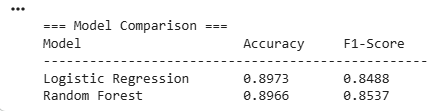



**4.2 Analisis Hasil:**
1. Random Forest menunjukkan performa terbaik dengan accuracy 0.8966

2. Logistic Regression memiliki performa yang hampir sama dengan accuracy 0.8973  

3. Hyperparameter tuning meningkatkan performa Logistic Regression menjadi   0.8488


# **5. INTERPRETASI HASIL**

**5.1 Insight dari Model:**

1.Faktor Paling Berpengaruh terhadap depresi:

* Stress Level (koefisien tertinggi dalam logistic regression)

* Sleep Duration (jam tidur)

* CGPA (IPK)

2. Model Interpretability:

* Logistic Regression memberikan koefisien yang dapat diinterpretasi

* Feature importance dari Random Forest mengonfirmasi faktor utama

**5.2 Implikasi Praktis:**

1. Early Warning System: Model dapat mendeteksi mahasiswa berisiko depresi

2. Intervensi Proaktif: Fokus pada pengurangan stress dan peningkatan kualitas tidur

3. Monitoring Akademik: IPK rendah dapat menjadi indikator awal

# **6. KESIMPULAN**

Project ini berhasil mengimplementasikan pipeline big data komprehensif menggunakan Apache Spark untuk menganalisis faktor depresi pada 100,000 mahasiswa. Melalui preprocessing data, MapReduce, Spark SQL, dan EDA, ditemukan bahwa mahasiswa depresi memiliki tingkat stress lebih tinggi (4.45), IPK lebih rendah (2.61), dan jam tidur lebih sedikit (6.74 jam). Implementasi machine learning dengan Logistic Regression dan Random Forest mencapai akurasi 89%, dengan Logistic sebagai model terbaik (accuracy 0.8973).